# 12 Telemetry And Trace Logging

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `12-telemetry-and-trace-logging.ipynb`

In [1]:
# ==========================================
# Notebook 12
# Telemetry and Trace Logging
# ==========================================

import uuid
import time
import random

import pandas as pd
import numpy as np

from datetime import datetime

import matplotlib.pyplot as plt

In [2]:
def generate_trace_id():

    return str(uuid.uuid4())

In [3]:
generate_trace_id()

'96c18ecc-9f98-4cc6-b13a-7859a6f6b0e8'

In [4]:
def create_trace_record(
    query,
    response,
    latency_ms,
    prompt_tokens,
    completion_tokens,
    cost,
    faithfulness,
    relevancy,
    recall,
    judge_score,
):

    return {
        "trace_id": generate_trace_id(),
        "timestamp": datetime.now(),
        "query": query,
        "response": response,
        "latency_ms": latency_ms,
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "total_tokens": prompt_tokens + completion_tokens,
        "cost_usd": cost,
        "faithfulness": faithfulness,
        "answer_relevancy": relevancy,
        "context_recall": recall,
        "judge_score": judge_score,
    }

In [5]:
trace = create_trace_record(
    query="What is AWS?",
    response="AWS is Amazon Web Services.",
    latency_ms=850,
    prompt_tokens=120,
    completion_tokens=60,
    cost=0.002,
    faithfulness=0.92,
    relevancy=0.95,
    recall=0.88,
    judge_score=0.90,
)

trace

{'trace_id': 'bff9fa08-5d2d-4fe5-b975-ee240d946798',
 'timestamp': datetime.datetime(2026, 6, 20, 11, 22, 57, 776144),
 'query': 'What is AWS?',
 'response': 'AWS is Amazon Web Services.',
 'latency_ms': 850,
 'prompt_tokens': 120,
 'completion_tokens': 60,
 'total_tokens': 180,
 'cost_usd': 0.002,
 'faithfulness': 0.92,
 'answer_relevancy': 0.95,
 'context_recall': 0.88,
 'judge_score': 0.9}

In [6]:
telemetry_logs = []

In [7]:
for i in range(100):

    log = create_trace_record(
        query=f"Query {i}",
        response=f"Response {i}",
        latency_ms=random.randint(300, 2500),
        prompt_tokens=random.randint(100, 800),
        completion_tokens=random.randint(50, 300),
        cost=round(random.uniform(0.001, 0.03), 4),
        faithfulness=round(random.uniform(0.6, 1.0), 2),
        relevancy=round(random.uniform(0.6, 1.0), 2),
        recall=round(random.uniform(0.6, 1.0), 2),
        judge_score=round(random.uniform(0.6, 1.0), 2),
    )

    telemetry_logs.append(log)

In [8]:
telemetry_df = pd.DataFrame(telemetry_logs)

telemetry_df.head()

,trace_id,timestamp,query,response,latency_ms,prompt_tokens,completion_tokens,total_tokens,cost_usd,faithfulness,answer_relevancy,context_recall,judge_score
0,2b011156-4a15-4a5c-9005-3ad54af10b74,2026-06-20 11:24:59.594948,Query 0,Response 0,1164,531,73,604,0.0041,0.72,0.73,0.66,0.68
1,4be2f9e9-acda-4c8f-ae95-f7fd73a04307,2026-06-20 11:24:59.594948,Query 1,Response 1,1555,620,84,704,0.0169,0.85,0.86,0.70,0.78
2,abf436a9-52dd-4577-a89d-bb098d682770,2026-06-20 11:24:59.594948,Query 2,Response 2,2491,430,141,571,0.0109,0.66,0.92,0.65,0.93
3,fc256be0-324a-4253-88cf-0540d435dc96,2026-06-20 11:24:59.594948,Query 3,Response 3,767,641,163,804,0.0253,0.73,0.61,0.98,0.75
4,35861e07-0619-4192-b1ff-e08793b23718,2026-06-20 11:24:59.594948,Query 4,Response 4,2269,284,237,521,0.0193,0.80,0.65,1.00,0.76


In [9]:
telemetry_df.describe()

,timestamp,latency_ms,prompt_tokens,completion_tokens,total_tokens,cost_usd,faithfulness,answer_relevancy,context_recall,judge_score
count,100,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,2026-06-20 11:24:59.594978048,1359.140000,442.360000,170.480000,612.840000,0.015860,0.79100,0.785400,0.778900,0.773800
min,2026-06-20 11:24:59.594948,339.000000,105.000000,50.000000,253.000000,0.001000,0.60000,0.610000,0.600000,0.610000
25%,2026-06-20 11:24:59.594948096,675.750000,309.000000,114.750000,472.250000,0.008000,0.68750,0.690000,0.690000,0.690000
50%,2026-06-20 11:24:59.594948096,1310.000000,449.000000,154.500000,617.000000,0.017900,0.80000,0.770000,0.760000,0.760000
75%,2026-06-20 11:24:59.594948096,2073.000000,590.750000,242.500000,769.250000,0.024100,0.90000,0.872500,0.872500,0.852500
max,2026-06-20 11:24:59.595948,2496.000000,776.000000,300.000000,1021.000000,0.029700,1.00000,1.000000,1.000000,1.000000
std,NaN,714.021928,185.399951,74.633986,190.281807,0.008615,0.12096,0.112523,0.110672,0.101859


In [10]:
telemetry_df["latency_ms"].mean()

1359.14

In [11]:
np.percentile(telemetry_df["latency_ms"], 95)

2416.2

In [12]:
np.percentile(telemetry_df["latency_ms"], 99)

2491.05

In [14]:
telemetry_df["total_tokens"].sum()

61284

In [15]:
telemetry_df["cost_usd"].sum()

1.5859999999999999

In [16]:
telemetry_df[
    ["faithfulness", "answer_relevancy", "context_recall", "judge_score"]
].mean()

faithfulness        0.7910
answer_relevancy    0.7854
context_recall      0.7789
judge_score         0.7738
dtype: float64

In [17]:
telemetry_df["quality_score"] = (
    telemetry_df["faithfulness"]
    + telemetry_df["answer_relevancy"]
    + telemetry_df["context_recall"]
    + telemetry_df["judge_score"]
) / 4

In [18]:
telemetry_df.head()

,trace_id,timestamp,query,response,latency_ms,prompt_tokens,completion_tokens,total_tokens,cost_usd,faithfulness,answer_relevancy,context_recall,judge_score,quality_score
0,2b011156-4a15-4a5c-9005-3ad54af10b74,2026-06-20 11:24:59.594948,Query 0,Response 0,1164,531,73,604,0.0041,0.72,0.73,0.66,0.68,0.6975
1,4be2f9e9-acda-4c8f-ae95-f7fd73a04307,2026-06-20 11:24:59.594948,Query 1,Response 1,1555,620,84,704,0.0169,0.85,0.86,0.70,0.78,0.7975
2,abf436a9-52dd-4577-a89d-bb098d682770,2026-06-20 11:24:59.594948,Query 2,Response 2,2491,430,141,571,0.0109,0.66,0.92,0.65,0.93,0.7900
3,fc256be0-324a-4253-88cf-0540d435dc96,2026-06-20 11:24:59.594948,Query 3,Response 3,767,641,163,804,0.0253,0.73,0.61,0.98,0.75,0.7675
4,35861e07-0619-4192-b1ff-e08793b23718,2026-06-20 11:24:59.594948,Query 4,Response 4,2269,284,237,521,0.0193,0.80,0.65,1.00,0.76,0.8025


In [19]:
slow_requests = telemetry_df[telemetry_df["latency_ms"] > 2000]

In [20]:
slow_requests[["trace_id", "latency_ms"]]

,trace_id,latency_ms
2,abf436a9-52dd-4577-a89d-bb098d682770,2491
4,35861e07-0619-4192-b1ff-e08793b23718,2269
6,d7d520d0-7153-4bb7-a47f-81450667ef05,2388
10,cdcbbd6a-ddd1-40e2-b212-a7b3799204fa,2202
11,da5a5149-7bee-4076-ac22-3c4bd35bd9cf,2496
13,4b430509-c4a0-46c8-9596-37cc61a35fd8,2305
21,16579f1b-68bd-4b6a-a37f-c4929b565dde,2362
22,76101ded-45a9-4c62-b439-8524fac53da9,2464
34,adafe16f-3f60-455a-8714-0884f099159a,2426
41,d95eea2a-2ef3-4c53-8cad-fa49421b32d5,2412


In [21]:
expensive_requests = telemetry_df[telemetry_df["cost_usd"] > 0.02]

In [22]:
expensive_requests[["trace_id", "cost_usd"]]

,trace_id,cost_usd
3,fc256be0-324a-4253-88cf-0540d435dc96,0.0253
6,d7d520d0-7153-4bb7-a47f-81450667ef05,0.0234
8,b207540b-d0e2-4406-9937-517032b0d333,0.0265
9,07e73fea-675e-4069-9d59-9699aba6f432,0.0202
11,da5a5149-7bee-4076-ac22-3c4bd35bd9cf,0.0202
20,dcbb57a5-446e-408d-8091-8510cc9db886,0.0238
25,fd989ff0-6469-44de-bcb2-7fdf80688073,0.0276
26,3dcc5ddb-3548-40d4-834c-abb2ce74bd3f,0.0244
27,3279c1fa-10ab-488f-b218-682f05aadc8b,0.0214
35,a5976c56-2e76-4c36-b8ee-754c9f79bd84,0.0297


In [23]:
low_quality = telemetry_df[telemetry_df["quality_score"] < 0.70]

In [24]:
low_quality[["trace_id", "quality_score"]]

,trace_id,quality_score
0,2b011156-4a15-4a5c-9005-3ad54af10b74,0.6975
8,b207540b-d0e2-4406-9937-517032b0d333,0.6625
15,b23fad5d-9a45-4fad-a191-1ab506dc9e83,0.6775
53,113a4e04-7cbf-45ad-846b-ff0d20558b24,0.6925
63,2f154cd1-6fdb-4892-9b23-3a4935af6575,0.6975
78,d0e86aab-fe3c-4841-90a8-f1e3631b93e7,0.6750


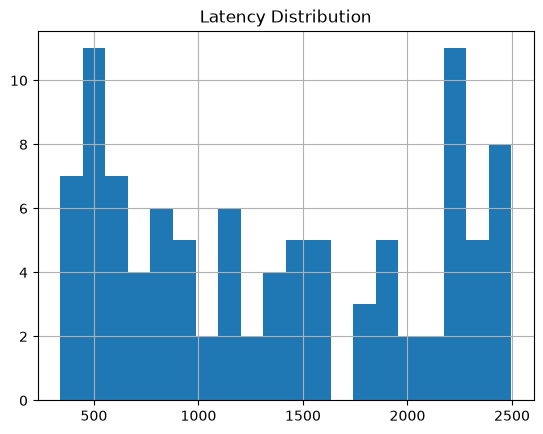

In [25]:
telemetry_df["latency_ms"].hist(bins=20)

plt.title("Latency Distribution")

plt.show()

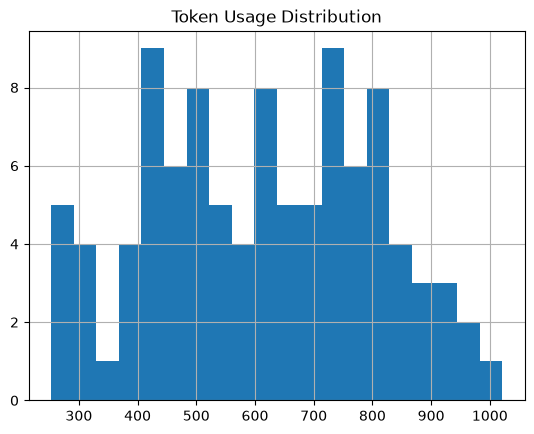

In [26]:
telemetry_df["total_tokens"].hist(bins=20)

plt.title("Token Usage Distribution")

plt.show()

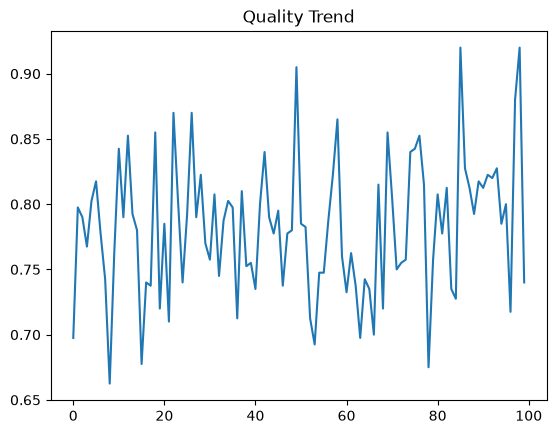

In [27]:
telemetry_df["quality_score"].plot()

plt.title("Quality Trend")

plt.show()

In [28]:
telemetry_df[["latency_ms", "total_tokens", "cost_usd", "quality_score"]].corr()

,latency_ms,total_tokens,cost_usd,quality_score
latency_ms,1.000000,-0.083370,-0.066378,0.098232
total_tokens,-0.083370,1.000000,0.032736,-0.012730
cost_usd,-0.066378,0.032736,1.000000,0.156029
quality_score,0.098232,-0.012730,0.156029,1.000000


In [29]:
P99 = np.percentile(telemetry_df["latency_ms"], 99)

In [30]:
anomalies = telemetry_df[
    (telemetry_df["latency_ms"] > P99) | (telemetry_df["quality_score"] < 0.60)
]

In [31]:
anomalies[["trace_id", "latency_ms", "quality_score"]]

,trace_id,latency_ms,quality_score
11,da5a5149-7bee-4076-ac22-3c4bd35bd9cf,2496,0.79


In [32]:
TRACE_SCHEMA = {
    "trace_id": "uuid",
    "timestamp": "datetime",
    "query": "string",
    "response": "string",
    "latency_ms": "float",
    "prompt_tokens": "int",
    "completion_tokens": "int",
    "cost_usd": "float",
    "faithfulness": "float",
    "answer_relevancy": "float",
    "context_recall": "float",
    "judge_score": "float",
}

In [33]:
dashboard = {
    "total_requests": len(telemetry_df),
    "avg_latency": round(telemetry_df["latency_ms"].mean(), 2),
    "p99_latency": round(P99, 2),
    "total_tokens": int(telemetry_df["total_tokens"].sum()),
    "total_cost": round(telemetry_df["cost_usd"].sum(), 4),
    "avg_quality": round(telemetry_df["quality_score"].mean(), 4),
}

dashboard

{'total_requests': 100,
 'avg_latency': 1359.14,
 'p99_latency': 2491.05,
 'total_tokens': 61284,
 'total_cost': 1.586,
 'avg_quality': 0.7823}

In [35]:
telemetry_df.to_csv("../telemetry/trace_logs.csv", index=False)

In [36]:
telemetry_df

,trace_id,timestamp,query,response,latency_ms,prompt_tokens,completion_tokens,total_tokens,cost_usd,faithfulness,answer_relevancy,context_recall,judge_score,quality_score
0,2b011156-4a15-4a5c-9005-3ad54af10b74,2026-06-20 11:24:59.594948,Query 0,Response 0,1164,531,73,604,0.0041,0.72,0.73,0.66,0.68,0.6975
1,4be2f9e9-acda-4c8f-ae95-f7fd73a04307,2026-06-20 11:24:59.594948,Query 1,Response 1,1555,620,84,704,0.0169,0.85,0.86,0.70,0.78,0.7975
2,abf436a9-52dd-4577-a89d-bb098d682770,2026-06-20 11:24:59.594948,Query 2,Response 2,2491,430,141,571,0.0109,0.66,0.92,0.65,0.93,0.7900
3,fc256be0-324a-4253-88cf-0540d435dc96,2026-06-20 11:24:59.594948,Query 3,Response 3,767,641,163,804,0.0253,0.73,0.61,0.98,0.75,0.7675
4,35861e07-0619-4192-b1ff-e08793b23718,2026-06-20 11:24:59.594948,Query 4,Response 4,2269,284,237,521,0.0193,0.80,0.65,1.00,0.76,0.8025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1bb508b2-9229-422f-86aa-768850398103,2026-06-20 11:24:59.594948,Query 95,Response 95,2266,278,264,542,0.0224,0.80,0.69,0.79,0.92,0.8000
96,f215cfaa-4ac4-429b-8385-46b387419f34,2026-06-20 11:24:59.594948,Query 96,Response 96,1871,439,132,571,0.0169,0.81,0.77,0.62,0.67,0.7175
97,01de12b2-ea7a-49d3-863b-9e7324c1a9b2,2026-06-20 11:24:59.595948,Query 97,Response 97,2412,451,54,505,0.0086,0.71,1.00,0.90,0.91,0.8800
98,d79f5b46-00af-4a51-b4a1-aa8b4b6fd1a4,2026-06-20 11:24:59.595948,Query 98,Response 98,746,168,203,371,0.0241,0.91,0.99,0.91,0.87,0.9200


In [38]:
pd.DataFrame([dashboard]).to_csv("../reports/dashboard_metrics.csv", index=False)